In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.txt to train.txt


In [2]:
filename = list(uploaded.keys())[0]

In [3]:
!pip install -q transformers

In [4]:
import pandas as pd
import csv
import numpy as np
import re
import string
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('GPU :', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

GPU : True
Device: cuda


#Convert data

In [5]:
with open(filename, encoding='utf-8') as file:
    data = file.readlines()

print(f'rows : {len(data)}')

errors = 0
with open('data.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=['source_txt', 'plagiarism_txt', 'label'])
    writer.writeheader()
    for line in tqdm(data, desc=' convert'):
        parts = line.strip().split('\t')
        if len(parts) < 3:
            errors += 1
            continue
        try:
            writer.writerow({
                'source_txt': parts[0],
                'plagiarism_txt': parts[1],
                'label': int(parts[2])
            })
        except Exception:
            errors += 1

print(f'✅ data.csv | skipped: {errors}')

rows : 367373


 convert:   0%|          | 0/367373 [00:00<?, ?it/s]

✅ data.csv | skipped: 0


## 5. Dataset Preprocessing

In [6]:
df = pd.read_csv('data.csv')
print(f' size: {df.shape}')
print(f'distribution Labels:\n{df["label"].value_counts()}')

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\n after :{df.shape}')

 size: (367373, 3)
distribution Labels:
label
0    183966
1    183407
Name: count, dtype: int64

 after :(366915, 3)


In [7]:
df.head()

,source_txt,plagiarism_txt,label
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


## 6 Cleaning

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['source_clean'] = df['source_txt'].apply(clean_text)
df['plag_clean']   = df['plagiarism_txt'].apply(clean_text)

print('✅ cleaned')
print('ex:')
print('before:', df['source_txt'][0])
print('after:', df['source_clean'][0])

✅ cleaned
ex:
before: A person on a horse jumps over a broken down airplane.
after: a person on a horse jumps over a broken down airplane.


## 7. Feature Extraction — BERT Tokenizer

In [9]:
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ BERT Tokenizer: {MODEL_NAME}')

#fine tuning
sample_df = df.sample(n=40000, random_state=42).reset_index(drop=True)
train_df, test_df = train_test_split(sample_df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Test: {len(test_df)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ BERT Tokenizer: sentence-transformers/all-MiniLM-L6-v2
Train: 32000 | Test: 8000


## 8. Dataset Class

In [10]:
class PlagiarismDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=64):
        self.data      = dataframe
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src   = str(self.data['source_clean'][idx])
        plag  = str(self.data['plag_clean'][idx])
        label = int(self.data['label'][idx])

        encoding = self.tokenizer(
            src, plag,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(label, dtype=torch.long)
        }

train_dataset = PlagiarismDataset(train_df, tokenizer_bert)
test_dataset  = PlagiarismDataset(test_df,  tokenizer_bert)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print('Dataset')
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Dataset
Train batches: 1000 | Test batches: 250


## 9. Model Training — BERT + Classifier (Fine-tuning)


In [11]:
class BERTPlagiarismClassifier(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        cls_output = self.dropout(cls_output)
        return self.classifier(cls_output)

model_bert = BERTPlagiarismClassifier(MODEL_NAME).to(device)
optimizer  = AdamW(model_bert.parameters(), lr=2e-5)
criterion  = nn.CrossEntropyLoss()

print(f'model ready')

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model ready


In [12]:
best_val_loss = float('inf')
patience = 2
patience_counter = 0
best_model_state = None

EPOCHS = 5
train_accs, val_accs, train_losses, val_losses = [], [], [], []

for epoch in range(EPOCHS):
    # Training
    model_bert.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} - Training'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model_bert(input_ids, attention_mask)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    train_acc  = correct / total
    train_loss = total_loss / len(train_loader)
    train_accs.append(train_acc)
    train_losses.append(train_loss)

    # Validation
    model_bert.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Epoch {epoch+1}/{EPOCHS} - Validation'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs        = model_bert(input_ids, attention_mask)
            loss           = criterion(outputs, labels)
            val_loss_total += loss.item()
            preds           = outputs.argmax(dim=1)
            val_correct    += (preds == labels).sum().item()
            val_total      += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = val_loss_total / len(test_loader)
    val_accs.append(val_acc)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_bert.state_dict().copy()
        print(f"Val loss improved → {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\n Early Stopping at Epoch {epoch+1}")
            break
    # ==========================================

if best_model_state:
    model_bert.load_state_dict(best_model_state)
    print("Loaded best model weights")

print('\n Fine-tuning ')

Epoch 1/5 - Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/5 - Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.8578 | Val Acc=0.9183 | Train Loss=0.3186 | Val Loss=0.2255
Val loss improved → 0.2255


Epoch 2/5 - Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/5 - Validation:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 4/5 - Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 4: Train Acc=0.9544 | Val Acc=0.9245 | Train Loss=0.1255 | Val Loss=0.2141
No improvement (1/2)


Epoch 5/5 - Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5/5 - Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 5: Train Acc=0.9644 | Val Acc=0.9306 | Train Loss=0.0971 | Val Loss=0.2102
No improvement (2/2)

 Early Stopping at Epoch 5
Loaded best model weights

 Fine-tuning 


## 10. Performance Evaluation

In [13]:
model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label']

        outputs = model_bert(input_ids, attention_mask)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

bert_acc = accuracy_score(all_labels, all_preds)
print(f'BERT Fine-tuned Accuracy: {bert_acc:.4f}')
print()
print(classification_report(all_labels, all_preds,
                             target_names=['Not Plagiarized', 'Plagiarized']))

BERT Fine-tuned Accuracy: 0.9306

                 precision    recall  f1-score   support

Not Plagiarized       0.93      0.93      0.93      3987
    Plagiarized       0.93      0.93      0.93      4013

       accuracy                           0.93      8000
      macro avg       0.93      0.93      0.93      8000
   weighted avg       0.93      0.93      0.93      8000



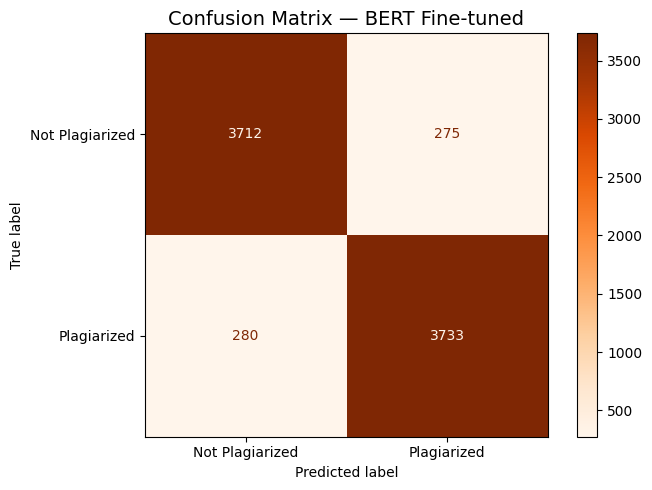

True Negatives  : 3712
False Positives : 275
False Negatives : 280
True Positives  : 3733


In [14]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Plagiarized', 'Plagiarized'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Oranges', ax=ax)
ax.set_title('Confusion Matrix — BERT Fine-tuned', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  : {tn}')
print(f'False Positives : {fp}')
print(f'False Negatives : {fn}')
print(f'True Positives  : {tp}')

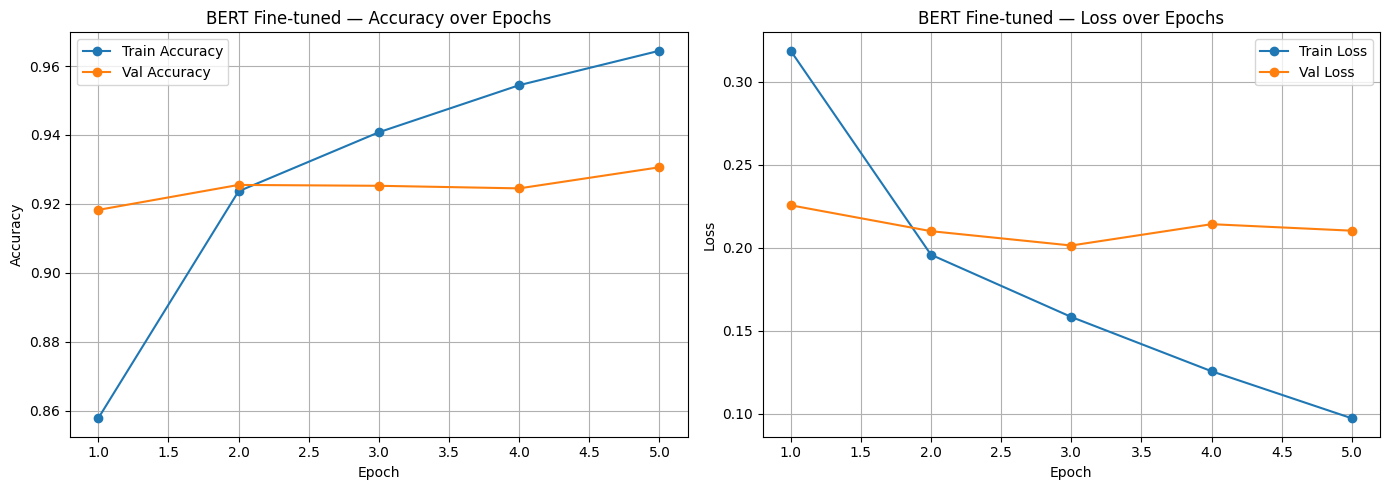

In [15]:
# Plot Accuracy & Loss
epochs_range = range(1, len(train_accs) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_accs, label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, val_accs,   label='Val Accuracy',   marker='o')
axes[0].set_title('BERT Fine-tuned — Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_losses, label='Train Loss', marker='o')
axes[1].plot(epochs_range, val_losses,   label='Val Loss',   marker='o')
axes[1].set_title('BERT Fine-tuned — Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
def predict_bert(source_text, plag_text):
    model_bert.eval()
    encoding = tokenizer_bert(
        source_text, plag_text,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model_bert(input_ids, attention_mask)
        probs   = torch.softmax(outputs, dim=1)
        pred    = outputs.argmax(dim=1).item()
        score   = probs[0][1].item()

    print(f'MAIN TEXT : {source_text}')
    print(f' PLAG TEXT : {plag_text}')
    print(f' Plagiarism probability  : {score:.4f}')
    print('✅ PLAGIARIZED' if pred == 1 else '❌ NOT Plagiarized')
    print('-' * 60)

predict_bert(
    'A woman is standing outside wearing glasses.',
    'A woman wearing glasses is outdoors.'
)

predict_bert(
    'Two kids are sleeping on a bench.',
    'A car is driving on the road.'
)

predict_bert(
    'The scientists discovered a new species of bird in the rainforest.',
    'Researchers found a previously unknown bird species in the jungle.'
)

MAIN TEXT : A woman is standing outside wearing glasses.
 PLAG TEXT : A woman wearing glasses is outdoors.
 Plagiarism probability  : 0.9974
✅ PLAGIARIZED
------------------------------------------------------------
MAIN TEXT : Two kids are sleeping on a bench.
 PLAG TEXT : A car is driving on the road.
 Plagiarism probability  : 0.0004
❌ NOT Plagiarized
------------------------------------------------------------
MAIN TEXT : The scientists discovered a new species of bird in the rainforest.
 PLAG TEXT : Researchers found a previously unknown bird species in the jungle.
 Plagiarism probability  : 0.9642
✅ PLAGIARIZED
------------------------------------------------------------
